In [1]:
import os
import copy
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

from src import utils, stats_utils
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

from src.data.datasets import EulfsDs

%load_ext autoreload
%autoreload 2

In [2]:
config_paths = "paths_config.yml"
config_data = "data_config.yml"

In [3]:
eulfs = EulfsDs(fn_config_path=config_paths, fn_config_data=config_data)

In [4]:
df_all = eulfs.read()

T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\data\datasets.py:1160: DtypeWarning: Columns (6,10) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(fpath, index_col=0)


In [10]:
df_all

,SEX,WSTATOR,NACE1D,ISCO3D,COUNTRYW,REGIONW,FTPT,REFYEAR,COUNTRY,REGION,...,COEFF_share_green_esco_median,COEFF_share_green_esco_iqr,COEFF_share_brown_esco_mean,COEFF_share_brown_esco_std,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr
0,1,1,C,132,AT,12,1.0,2019,AT,10,...,1.280184,3.206847,1.332174,2.898123,0.0000,1.812367,78.347373,6.256753,79.705862,5.159531
1,1,1,G,311,AT,12,1.0,2019,AT,10,...,2.621375,6.272751,1.219204,2.907287,0.0000,1.476227,74.077524,13.100073,78.316253,9.437091
2,2,1,G,411,AT,12,1.0,2019,AT,10,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,47.232500,0.000000,47.232500,0.000000
3,2,1,Q,911,AT,12,1.0,2019,AT,10,...,2.521190,1.334058,0.518645,0.902814,0.0000,0.756357,49.757904,1.892336,49.919571,1.359269
4,2,1,R,265,AT,12,1.0,2019,AT,10,...,0.000000,0.000000,0.468287,1.913457,0.0000,0.000000,75.130802,2.555652,75.862500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1591101,1,2,G,421,UK,M0,2.0,2019,UK,M0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1098.125092,7.539097,1100.140000,0.000000
1591102,1,1,O,211,UK,M0,1.0,2019,UK,M0,...,81.391364,241.461045,81.733828,130.918147,29.8435,99.478333,1533.571009,328.865733,1690.013933,244.983955
1591103,1,1,H,833,UK,M0,1.0,2019,UK,M0,...,59.957419,68.310462,40.006625,69.027988,0.0000,64.235318,1700.616274,208.502745,1722.679024,147.931174
1591104,2,1,Q,263,UK,M0,1.0,2019,UK,M0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1719.166319,16.951764,1723.300000,0.000000


In [11]:
# retrieve cols that should be aggregated across NUTS codes
cols_to_calc = df_all.columns[df_all.columns.str.startswith("COEFF_")].to_list()
cols_to_calc_all = copy.copy(cols_to_calc)
cols_to_calc_all.insert(0, "COEFF")

# get correct shapefile
epsg = "3035"
gdf_digits_match = eulfs.gdf_nuts[epsg].loc[eulfs.gdf_nuts[epsg]["LEVL_CODE"] == eulfs.n_digits_nuts]

# aggregate over regions
df_all_agg = df_all.groupby("NUTS_ID")[cols_to_calc_all].sum().reset_index()

gdf_sub = pd.merge(
    gdf_digits_match,
    df_all_agg,
    on="NUTS_ID",
    how="left"
)

In [12]:
# calculate relative shares at regional level
for col in cols_to_calc:
    gdf_sub["{}_relative".format(col)] = gdf_sub[col] / gdf_sub["COEFF"]

In [36]:
# TODO: why not working?
def extract_cols(df, sw=None, ew=None):
    if sw is not None:
        cond_sw = df.columns.str.startswith(sw)
    if ew is not None:
        cond_ew = df.columns.str.endswith(sw)

    matching_cols = df.columns[cond_sw & cond_ew]

    return matching_cols.to_list()

cols_to_plot = extract_cols(gdf_sub, sw="COEFF_", ew="relative")
cols_to_plot

[False False False False False False False False False False False  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True]
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False]


[]

#### Reproject
My recommendation is to use the Lambert Azimuthal Equal Area projection (based on
ETRS 89), with EPSG code = 3035 (EPSG:3035). This projection covers the all of Europe, is part of the standard for the INSPIRE directive, and does not distort the area (which is important if you compute statistics of land use).

http://bboxfinder.com/#34.741612,-11.953125,71.469124,32.695313

Map of Europe

In [41]:
cols_to_plot = gdf_sub.columns[gdf_sub.columns.str.startswith("COEFF_") & gdf_sub
    .columns.str.endswith("relative")].to_list()

gdf_nuts_0 = eulfs.gdf_nuts[epsg].loc[eulfs.gdf_nuts[epsg]["LEVL_CODE"] == 0]

In [69]:
# bbox
# bbox_eu_epsg_4326 = [-11.953125,34.741612,32.695313,71.469124]
bbox_eu_epsg_3035 = np.array([2.5, 6, 1.3, 5.5]) * 1e6
xmin, xmax, ymin, ymax = bbox_eu_epsg_3035.tolist()

# figure params
figsize = (10, 10)
legend=True
cbar_label = "Employment fraction [-]"
missing_kwds = {"facecolor": "white", "hatch": "//", "edgecolor": "grey"}
legend_kwds = {"label": cbar_label, "fraction": 0.03, "extend": "max"}
edgecolor = "grey"
linewidth = 0.5

# percentiles for robust cmaps
p_high, p_low = 98, 2

for column in cols_to_plot:
    # create figure
    fig, ax = plt.subplots(figsize=figsize)

    # dynamically set n categories and vmax
    q_high, q_low = np.nanpercentile(gdf_sub[column].values, q=[p_high, p_low])
    n_cats = np.ceil(q_high * 100)
    #vmax = np.ceil(gdf_sub[column].max() * 100) / 100
    cmap = plt.get_cmap("Greys")

    # plot data
    gdf_sub.plot(
        ax=ax,
        column=column,
        figsize=figsize,
        legend=legend,
        cmap=cmap,
        vmax=q_high,
        vmin=0,
        missing_kwds=missing_kwds,
        legend_kwds=legend_kwds,
        edgecolor=edgecolor,
        linewidth=linewidth
    )

    # add country borders (NUTS 0)
    gdf_nuts_0.geometry.boundary.plot(
        ax=ax,
        color=None,
        edgecolor="black",
        linewidth=0.5
    )

    # labelling
    ax.set_title(column)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    #ax.set_xlabel("Longitude [°]")
    #ax.set_ylabel("Latitude [°]")

    ax.axis('off')

    plt.tight_layout()

    plt.savefig(
        os.path.join(eulfs.figure_dir, "eulfs", "{}.png".format(column)),
        dpi=150,
        bbox_inches="tight"
    )

    plt.close(fig)

Shares by industry

In [92]:
# aggregate over industries and countries
df_all_agg_by_cntr_ind = df_all.groupby(["NACE1D_label", "COUNTRYW"])[cols_to_calc_all]\
    .sum()\
    .reset_index()

cols = ["COEFF_share_green_gtp_mean", "COEFF_share_green_esco_mean",
        "COEFF_share_brown_esco_mean", "COEFF_share_neutral_esco_mean"]

for col in cols:
    df_all_agg_by_cntr_ind["{}_relative".format(col)] = df_all_agg_by_cntr_ind[col] / df_all_agg_by_cntr_ind["COEFF"]

In [93]:
df_all_agg_by_cntr_ind

,NACE1D_label,COUNTRYW,COEFF,COEFF_share_green_gtp_mean,COEFF_share_green_gtp_std,COEFF_share_green_gtp_median,COEFF_share_green_gtp_iqr,COEFF_share_green_esco_mean,COEFF_share_green_esco_std,COEFF_share_green_esco_median,...,COEFF_share_brown_esco_median,COEFF_share_brown_esco_iqr,COEFF_share_neutral_esco_mean,COEFF_share_neutral_esco_std,COEFF_share_neutral_esco_median,COEFF_share_neutral_esco_iqr,COEFF_share_green_gtp_mean_relative,COEFF_share_green_esco_mean_relative,COEFF_share_brown_esco_mean_relative,COEFF_share_neutral_esco_mean_relative
0,Accommodation and Food Service Activities,AT,2.648434e+05,4504.027266,1174.010304,4450.039425,569.364836,8765.615838,8900.930074,6735.681227,...,862.539431,1629.213189,2.544062e+05,9567.922096,2.571074e+05,8462.186106,0.017006,0.033097,0.006312,0.960591
1,Accommodation and Food Service Activities,BE,1.802910e+05,2188.394310,1136.035929,1850.270863,342.142951,6885.695658,6264.396107,6437.263194,...,380.234117,679.266829,1.725586e+05,6660.162741,1.734256e+05,6336.523519,0.012138,0.038192,0.004696,0.957112
2,Accommodation and Food Service Activities,BG,1.773203e+05,0.000000,0.000000,0.000000,0.000000,2.706296,7.504087,0.000000,...,0.000000,0.000000,9.464523e+02,9.530256,9.514700e+02,7.617045,0.000000,0.000015,0.000013,0.005338
3,Accommodation and Food Service Activities,CH,1.874475e+05,6083.046815,2010.242553,5685.997656,1260.231537,6400.587003,6462.723273,5436.009831,...,594.659553,1157.808646,1.789266e+05,7078.632678,1.804076e+05,6527.036965,0.032452,0.034146,0.006381,0.954542
4,Accommodation and Food Service Activities,CZ,1.897411e+05,1121.528140,195.075064,1102.539610,103.497606,5150.469312,6322.071281,3046.640329,...,686.422921,1031.400432,1.834076e+05,6822.794409,1.860680e+05,5586.769110,0.005911,0.027145,0.006235,0.966620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Wholesale and Retail Trade; Repair of Motor Ve...,PT,7.017188e+05,86359.287627,23564.821911,82954.929418,12824.069742,15077.194719,21262.804596,8316.784752,...,2700.246173,6115.898166,6.811541e+05,23982.195529,6.879916e+05,16457.670020,0.123068,0.021486,0.007820,0.970694
477,Wholesale and Retail Trade; Repair of Motor Ve...,RO,1.266177e+06,153914.198957,50167.744887,146824.598735,29600.018926,21295.377572,36798.304741,9501.423807,...,4868.968589,11819.559055,1.234879e+06,42893.009046,1.247458e+06,26216.406303,0.121558,0.016819,0.007899,0.975282
478,Wholesale and Retail Trade; Repair of Motor Ve...,SE,5.687602e+05,96385.736840,29154.618854,92266.365282,13849.318267,14469.785640,24127.397733,6981.679570,...,1773.614022,5277.024560,5.492589e+05,27986.760808,5.580149e+05,16134.556411,0.169466,0.025441,0.008846,0.965713
479,Wholesale and Retail Trade; Repair of Motor Ve...,SK,2.999156e+05,36702.099527,10929.740777,34932.499754,5439.732398,5337.704108,8728.628137,2761.488611,...,661.807488,1813.147963,2.869142e+05,9946.721031,2.899569e+05,5500.578585,0.122375,0.017797,0.005910,0.956650


<AxesSubplot:xlabel='COEFF_share_green_esco_mean_relative', ylabel='NACE1D_label'>

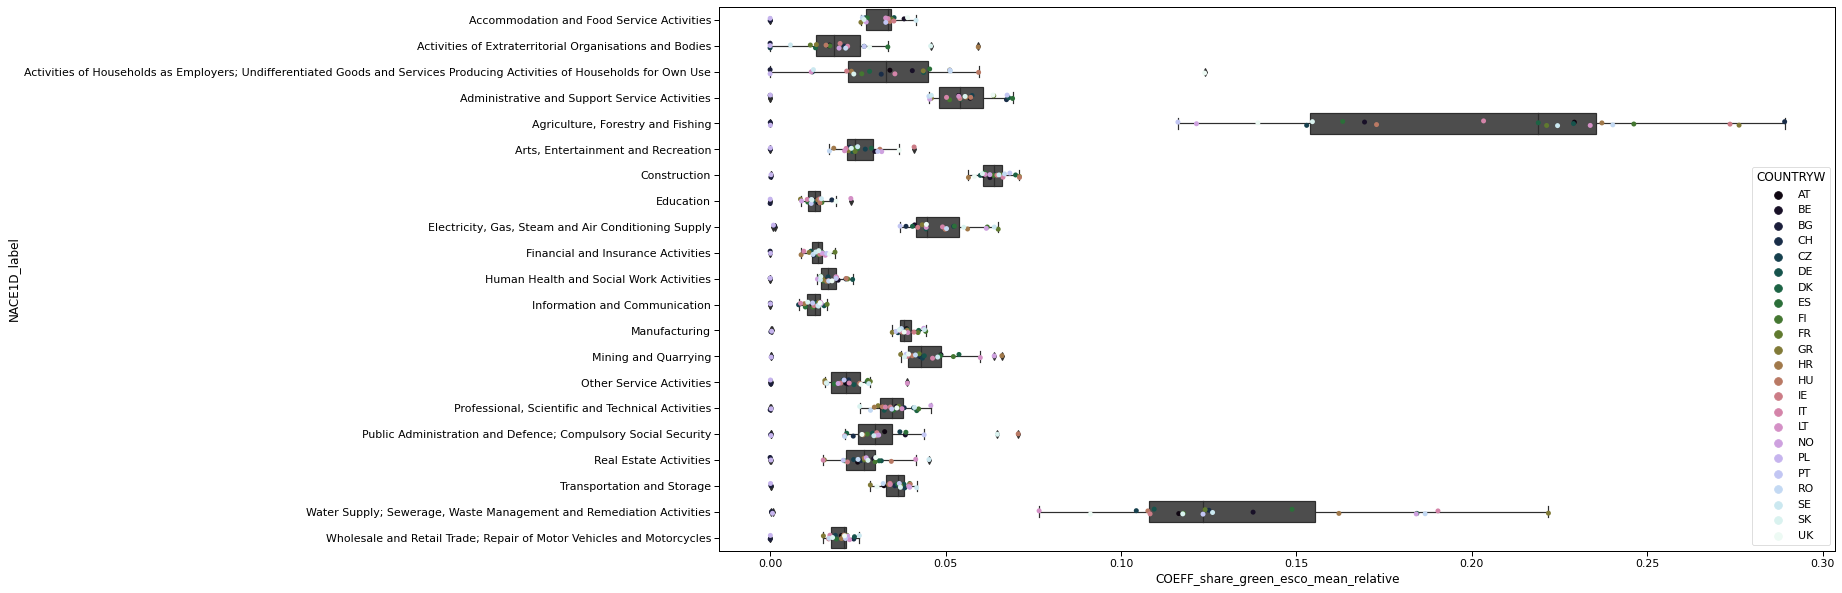

In [110]:
f, ax = plt.subplots(figsize=(20, 10))

x_var = "COEFF_share_green_esco_mean_relative"
y_var = "NACE1D_label"
hue_var = "COUNTRYW"

n_colors = len(df_all_agg_by_cntr_ind[hue_var].unique())
palette = sns.color_palette("cubehelix", n_colors=n_colors)

sns.boxplot(
    data=df_all_agg_by_cntr_ind,
    x=x_var,
    y=y_var,
    color=".3",
)

sns.stripplot(
    data=df_all_agg_by_cntr_ind,
    x=x_var,
    y=y_var,
    #color=".3",
    hue=hue_var,
    palette=palette
)

sns.despine()

<AxesSubplot:xlabel='COEFF_share_green_gtp_mean_relative', ylabel='NACE1D_label'>

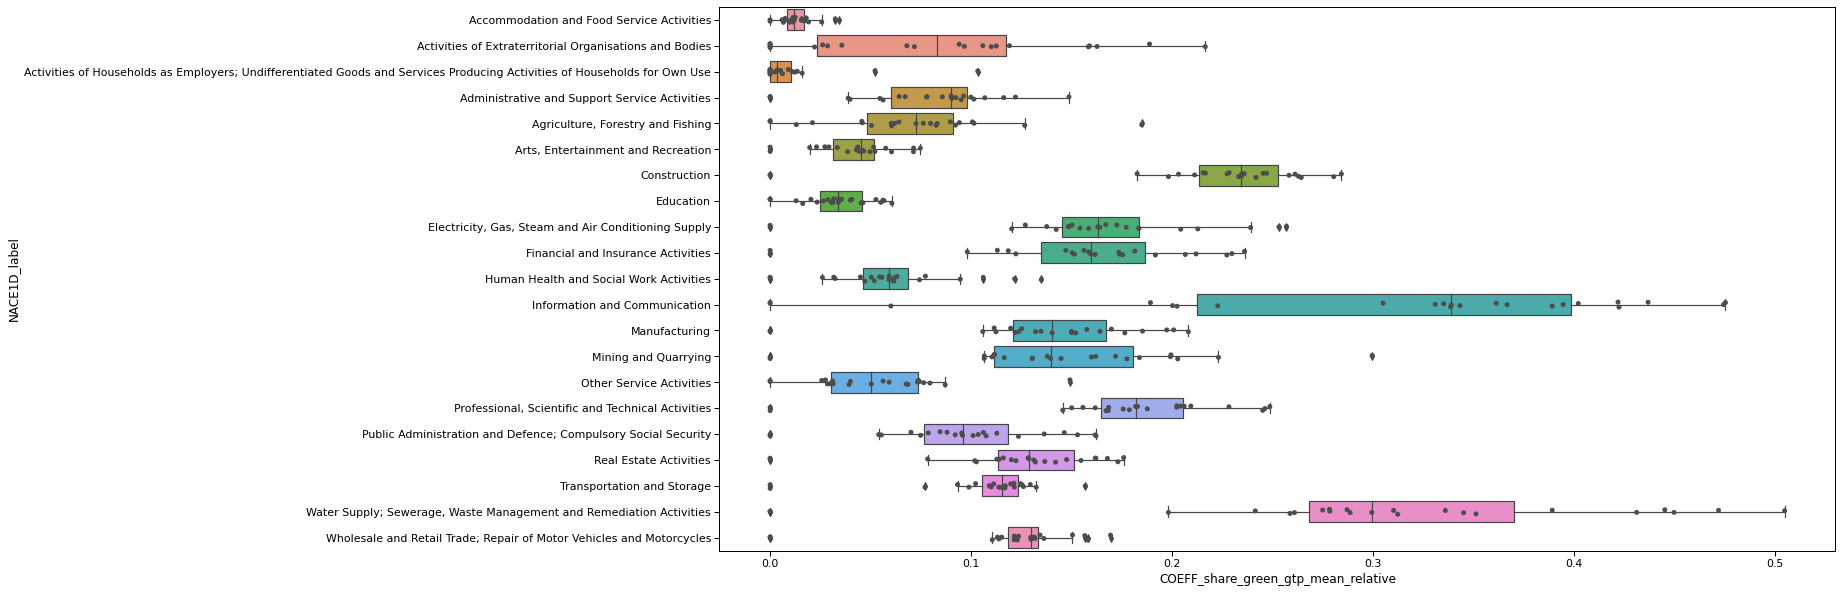

In [103]:
f, ax = plt.subplots(figsize=(20, 10))

sns.boxplot(
    data=df_all_agg_by_cntr_ind,
    x="COEFF_share_green_gtp_mean_relative",
    y="NACE1D_label",
)

sns.stripplot(
    data=df_all_agg_by_cntr_ind,
    x="COEFF_share_green_gtp_mean_relative",
    y="NACE1D_label",
    color=".3"
)

<AxesSubplot:xlabel='COEFF_share_brown_esco_mean_relative', ylabel='NACE1D_label'>

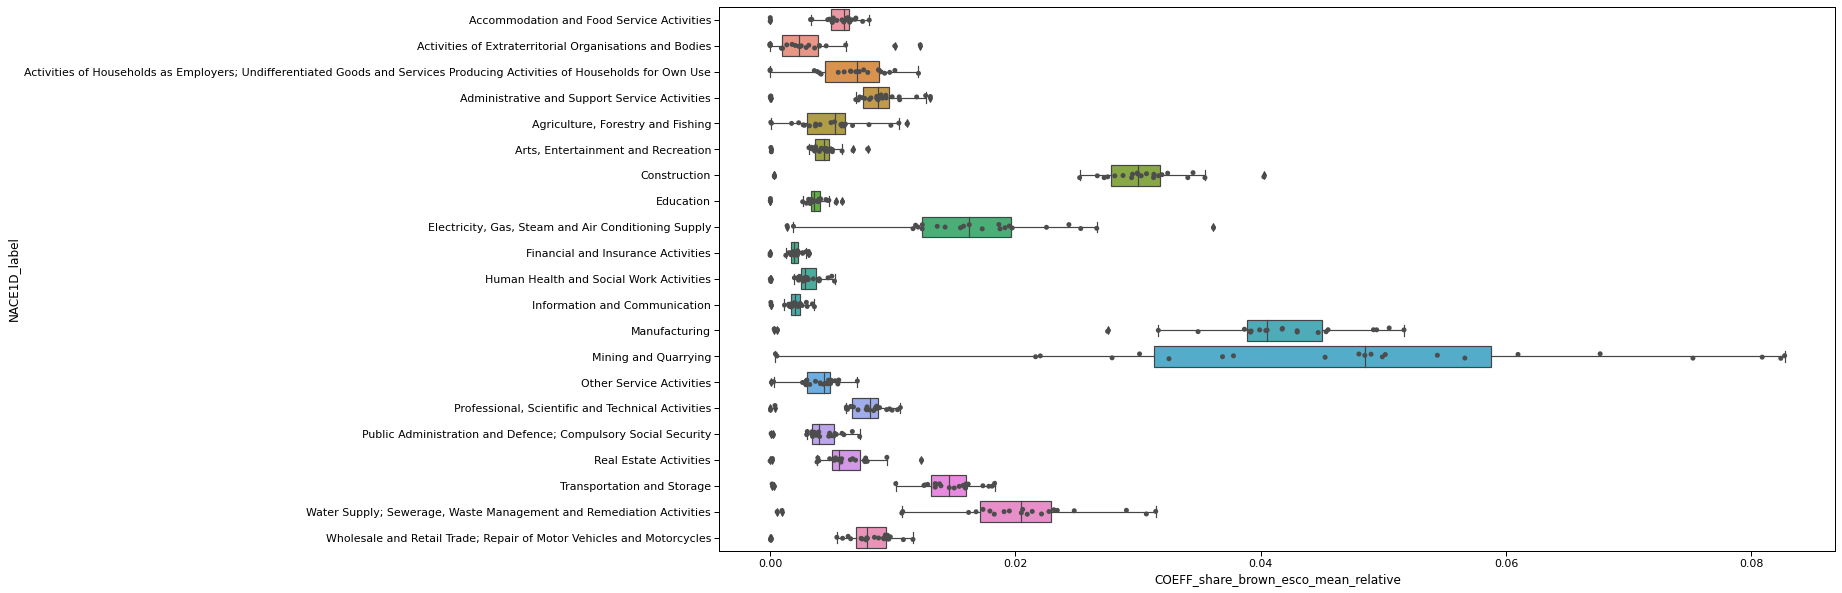

In [104]:
f, ax = plt.subplots(figsize=(20, 10))

sns.boxplot(
    data=df_all_agg_by_cntr_ind,
    x="COEFF_share_brown_esco_mean_relative",
    y="NACE1D_label",
)

sns.stripplot(
    data=df_all_agg_by_cntr_ind,
    x="COEFF_share_brown_esco_mean_relative",
    y="NACE1D_label",
    color=".3"
)

Shares by age

In [80]:
age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",
                           "COEFF_share_brown_esco_mean",
                      "COEFF_share_neutral_esco_mean"].sum()

coeff_by_age = df_all.groupby("AGE")["COEFF"].sum()

C:\Users\fzaussinger\AppData\Local\Temp\ipykernel_5720\3363292881.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  age_by_gbn_shares = df_all.groupby("AGE")["COEFF_share_green_esco_mean",


In [82]:
age_by_gbn_shares_rel = age_by_gbn_shares.copy()
for col in age_by_gbn_shares_rel.columns:
    age_by_gbn_shares_rel[col] = age_by_gbn_shares_rel[col] / coeff_by_age

<AxesSubplot:xlabel='AGE'>

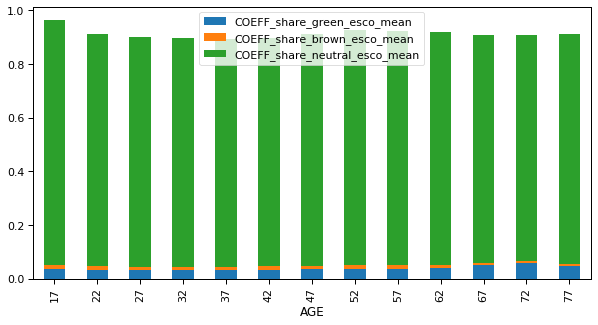

In [85]:
age_by_gbn_shares_rel.plot.bar(stacked=True, figsize=(10, 5))